# Input Analysis
Analysing the Input Data (the request data received from LCO) for patterns and insights.

## Setup

### Load Libraries

In [45]:
import pandas as pd
import pickle
import json
import os
import datetime as dt
from matplotlib import pyplot as plt
import re
import numpy as np
import seaborn as sns

ValueError: numpy.ndarray size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

### Set variables

In [2]:
root = "D:/_DATA_ANALYSIS_FILES"
print(os.path.isdir(root))

True


## Load Data

### Load 1m Data

In [3]:
dataframes = []
for i in range(10):
    print(f"\r{i}", end="")
    filepath = os.path.join(root, f"1m_condensed_{i}.pkldf")
    dataframes.append(pd.read_pickle(filepath))
print("\r", end="")
df1 = pd.concat(dataframes).drop(columns=["og_file"])
df1

,original_windows,windows,id,ipp_value,created,proposal_id,optimization_type,total_duration,acceptibility_cutoff,valid_telescopes
2337608,"[{'start': 2020-12-22 07:57:37, 'end': 2020-12...",{'1m0a.doma.tfn': Timestamp('2020-12-23 04:58:...,2337608,1.0,2020-12-22T07:55:38.646Z,KEY2020B-006,TIME,1398,1398.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ..."
2149231,"[{'start': 2020-06-13 08:30:19.488000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2020-06-13 21:03:...,2149231,0.9,2020-06-13T08:30:23.476Z,KEY2017AB-001,TIME,2318,2318.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ..."
2149281,"[{'start': 2020-06-13 09:50:44.345000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2020-06-13 21:03:...,2149281,1.2,2020-06-13T09:50:49.620Z,KEY2017AB-001,TIME,2025,2025.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ..."
2379046,"[{'start': 2021-02-03 18:35:27.970000, 'end': ...",{'1m0a.domc.cpt': Timestamp('2021-02-03 18:35:...,2379046,1.05,2021-02-03T11:00:24.757Z,auto_focus,TIME,542,542.0,[1m0a.domc.cpt]
2379039,"[{'start': 2021-02-03 18:35:27.970000, 'end': ...",{'1m0a.domb.cpt': Timestamp('2021-02-03 18:35:...,2379039,1.05,2021-02-03T11:00:16.184Z,auto_focus,TIME,542,542.0,[1m0a.domb.cpt]
...,...,...,...,...,...,...,...,...,...,...
2546089,"[{'start': 2021-06-10 00:54:06.612000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2021-06-10 21:01:...,2546089,1.02,2021-06-10T00:54:08.936Z,CON2021A-012,TIME,766,766.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ..."
2546088,"[{'start': 2021-06-10 00:54:03.624000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2021-06-10 21:01:...,2546088,1.02,2021-06-10T00:54:06.016Z,CON2021A-012,TIME,566,566.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ..."
2546087,"[{'start': 2021-06-10 00:54:01.426000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2021-06-10 21:01:...,2546087,1.02,2021-06-10T00:54:03.318Z,CON2021A-012,TIME,566,566.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ..."
2546086,"[{'start': 2021-06-10 00:53:59.184000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2021-06-10 21:01:...,2546086,1.02,2021-06-10T00:54:01.010Z,CON2021A-012,TIME,566,566.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ..."


### Load 2m Data

In [4]:
df2 = pd.read_pickle(os.path.join(root, "2m_large_all.pkldf"))
df2

,original_windows,windows,id,ipp_value,created,proposal_id,optimization_type,total_duration,acceptibility_cutoff,valid_telescopes,target_constraint_pairs
2070067,"[{'start': 2020-02-26 08:00:22.880000, 'end': ...",{'2m0a.clma.ogg': Timestamp('2020-02-26 08:00:...,2070067,0.95,2020-02-26T08:00:25.724Z,KEY2017AB-001,TIME,3345,3344.5,"[2m0a.clma.coj, 2m0a.clma.ogg]","[{'target': {'id': 3794395, 'name': 'SN2019xdf..."
2074257,"[{'start': 2020-02-29 08:24:00, 'end': 2020-02...",{'2m0a.clma.coj': Timestamp('2020-02-29 12:54:...,2074257,1.05,2020-02-29T08:03:33.408Z,FTPEPO2014A-004,TIME,317,317.0,"[2m0a.clma.coj, 2m0a.clma.ogg]","[{'target': {'id': 3810533, 'name': '2016 UJ10..."
2074133,"[{'start': 2020-02-29 10:32:42.554000, 'end': ...",{'2m0a.clma.coj': Timestamp('2020-02-29 10:32:...,2074133,1.05,2020-02-29T02:00:40.155Z,auto_focus,TIME,720,720.0,[2m0a.clma.coj],"[{'target': {'id': 3809568, 'name': 'auto_focu..."
2074134,"[{'start': 2020-02-29 11:32:42.554000, 'end': ...",{'2m0a.clma.coj': Timestamp('2020-02-29 11:32:...,2074134,1.05,2020-02-29T02:00:41.027Z,auto_focus,TIME,720,720.0,[2m0a.clma.coj],"[{'target': {'id': 3809569, 'name': 'auto_focu..."
2149114,"[{'start': 2020-06-13 09:04:44.596000, 'end': ...",{'2m0a.clma.coj': Timestamp('2020-06-13 09:04:...,2149114,1.05,2020-06-13T02:00:42.445Z,auto_focus,TIME,720,720.0,[2m0a.clma.coj],"[{'target': {'id': 4230328, 'name': 'auto_focu..."
...,...,...,...,...,...,...,...,...,...,...,...
2628675,"[{'start': 2021-08-31 18:39:40.818000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-08-31 18:39:...,2628675,1.05,2021-08-31T02:00:52.062Z,auto_focus,TIME,720,720.0,[2m0a.clma.coj],"[{'target': {'id': 6531444, 'name': 'auto_focu..."
2628924,"[{'start': 2021-08-31 11:55:25.041000, 'end': ...",{'2m0a.clma.ogg': Timestamp('2021-08-31 11:55:...,2628924,1.0,2021-08-31T11:55:29.112Z,NSF2021B-019,TIME,1740,1740.0,"[2m0a.clma.coj, 2m0a.clma.ogg]","[{'target': {'id': 6533080, 'name': 'ZTF20acgi..."
2546029,"[{'start': 2021-06-10 00:30:21.276000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-06-10 12:56:...,2546029,1.0,2021-06-10T00:30:30.609Z,KEY2020B-002,TIME,4245,4244.5,"[2m0a.clma.coj, 2m0a.clma.ogg]","[{'target': {'id': 6101526, 'name': 'SN2021hku..."
2625941,"[{'start': 2021-08-28 00:00:04.674000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-08-28 13:07:...,2625941,0.9,2021-08-28T00:00:21.972Z,KEY2020B-002,TIME,1245,1244.5,"[2m0a.clma.coj, 2m0a.clma.ogg]","[{'target': {'id': 6516191, 'name': 'SN2021rhu..."


In [5]:
s1 = set(df1.columns)
s2 = set(df2.columns)
print(s1.intersection(s2))
print("a", s2-s1)
print("b", s1-s2)

{'valid_telescopes', 'id', 'created', 'windows', 'original_windows', 'optimization_type', 'total_duration', 'ipp_value', 'acceptibility_cutoff', 'proposal_id'}
a {'target_constraint_pairs'}
b set()


### Merge Together

In [6]:
df1["class"] = "1m"
df2["class"] = "2m"
df = pd.concat([df1, df2])
df.rename(columns={"id": "request_id"}, inplace=True)
del df1
del df2
df

,original_windows,windows,request_id,ipp_value,created,proposal_id,optimization_type,total_duration,acceptibility_cutoff,valid_telescopes,class,target_constraint_pairs
2337608,"[{'start': 2020-12-22 07:57:37, 'end': 2020-12...",{'1m0a.doma.tfn': Timestamp('2020-12-23 04:58:...,2337608,1.0,2020-12-22T07:55:38.646Z,KEY2020B-006,TIME,1398,1398.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN
2149231,"[{'start': 2020-06-13 08:30:19.488000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2020-06-13 21:03:...,2149231,0.9,2020-06-13T08:30:23.476Z,KEY2017AB-001,TIME,2318,2318.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN
2149281,"[{'start': 2020-06-13 09:50:44.345000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2020-06-13 21:03:...,2149281,1.2,2020-06-13T09:50:49.620Z,KEY2017AB-001,TIME,2025,2025.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN
2379046,"[{'start': 2021-02-03 18:35:27.970000, 'end': ...",{'1m0a.domc.cpt': Timestamp('2021-02-03 18:35:...,2379046,1.05,2021-02-03T11:00:24.757Z,auto_focus,TIME,542,542.0,[1m0a.domc.cpt],1m,NaN
2379039,"[{'start': 2021-02-03 18:35:27.970000, 'end': ...",{'1m0a.domb.cpt': Timestamp('2021-02-03 18:35:...,2379039,1.05,2021-02-03T11:00:16.184Z,auto_focus,TIME,542,542.0,[1m0a.domb.cpt],1m,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2628675,"[{'start': 2021-08-31 18:39:40.818000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-08-31 18:39:...,2628675,1.05,2021-08-31T02:00:52.062Z,auto_focus,TIME,720,720.0,[2m0a.clma.coj],2m,"[{'target': {'id': 6531444, 'name': 'auto_focu..."
2628924,"[{'start': 2021-08-31 11:55:25.041000, 'end': ...",{'2m0a.clma.ogg': Timestamp('2021-08-31 11:55:...,2628924,1.0,2021-08-31T11:55:29.112Z,NSF2021B-019,TIME,1740,1740.0,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6533080, 'name': 'ZTF20acgi..."
2546029,"[{'start': 2021-06-10 00:30:21.276000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-06-10 12:56:...,2546029,1.0,2021-06-10T00:30:30.609Z,KEY2020B-002,TIME,4245,4244.5,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6101526, 'name': 'SN2021hku..."
2625941,"[{'start': 2021-08-28 00:00:04.674000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-08-28 13:07:...,2625941,0.9,2021-08-28T00:00:21.972Z,KEY2020B-002,TIME,1245,1244.5,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6516191, 'name': 'SN2021rhu..."


### Load General Data

#### Get Request IDs

In [7]:
request_ids = df["request_id"].unique().tolist()
len(request_ids)

512963

#### Get Request Data

In [8]:
condensed_request_path = os.path.join(root, "request_data.pkldf")

if os.path.isfile(condensed_request_path):
    df_request = pd.read_pickle(condensed_request_path)
    
else:
    df_list_request = []
    for filename in os.listdir(root):
        if "_request." in filename:
            filepath = os.path.join(root, filename)
            data = pickle.load(open(filepath, "rb"))
            data = data[data["id"].isin(request_ids)]
            df_list_request.append(data)
    df_request = pd.concat(df_list_request)
    del df_list_request
    df_request = df_request[["id", "state", "modified", "acceptability_threshold", "configuration_repeats", "request_group_id"]]
    df_request.rename(columns={"id": "request_id"}, inplace=True)
    df_request.to_pickle(condensed_request_path)

requestgroup_ids = df_request["request_group_id"].unique().tolist()
df_request

,request_id,state,modified,acceptability_threshold,configuration_repeats,request_group_id
1,3097579,COMPLETED,2023-01-28T02:54:33.079Z,90.0,1,1615811
3,3112564,COMPLETED,2023-01-29T01:32:09.843Z,90.0,1,1628904
4,3112973,COMPLETED,2023-01-29T01:35:53.039Z,90.0,1,1629274
5,3097636,COMPLETED,2023-01-29T01:37:35.191Z,90.0,1,1615821
9,2816102,COMPLETED,2022-03-17T02:22:10.561Z,90.0,1,1414793
...,...,...,...,...,...,...
1062529,2327171,WINDOW_EXPIRED,2020-12-14T02:45:07.843Z,90.0,1,1107821
1062532,2327168,WINDOW_EXPIRED,2020-12-14T10:25:07.398Z,90.0,1,1107818
1062590,2359397,COMPLETED,2021-01-18T09:16:10.853Z,90.0,1,1131247
1062592,2359738,WINDOW_EXPIRED,2021-01-18T18:15:03.922Z,90.0,1,1131558


#### Get Requestgroup Data

In [9]:
condensed_group_path = os.path.join(root, "group_data.pkldf")

if os.path.isfile(condensed_group_path) and False:
    df_group = pd.read_pickle(condensed_group_path)
    
else:
    filename = "requestgroups_requestgroup.pkl"
    filepath = os.path.join(root, filename)
    df_group = pickle.load(open(filepath, "rb"))
    df_group = df_group[["id", "state"]]
    df_group.rename(columns={"id": "request_group_id", "state": "request_group_state"}, inplace=True)
    df_group.to_pickle(condensed_group_path)

df_group

,request_group_id,request_group_state
0,1381010,PENDING
1,1083530,WINDOW_EXPIRED
2,947053,WINDOW_EXPIRED
3,1001499,WINDOW_EXPIRED
4,1001493,WINDOW_EXPIRED
...,...,...
691928,1232876,WINDOW_EXPIRED
691929,1232875,WINDOW_EXPIRED
691930,1232874,WINDOW_EXPIRED
691931,1232873,WINDOW_EXPIRED


#### Get Configuration Data

In [10]:
condensed_config_path = os.path.join(root, "configuration_data.pkldf")

if os.path.isfile(condensed_config_path):
    df_config = pd.read_pickle(condensed_config_path)
    
else:
    df_list_config = []
    for filename in os.listdir(root):
        if "_configuration_" in filename:
            filepath = os.path.join(root, filename)
            data = pickle.load(open(filepath, "rb"))
            data = data[data["request_id"].isin(request_ids)]
            df_list_config.append(data)
    df_config = pd.concat(df_list_config)
    del df_list_config
    df_config.drop(columns=["extra_params", "priority"], inplace=True)
    df_config.rename(columns={"id": "configuration_id"}, inplace=True)
    df_config.to_pickle(condensed_config_path)

config_ids = df_config["configuration_id"].unique().tolist()
df_config

,configuration_id,instrument_type,type,request_id,repeat_duration
5,4062711,1M0-SCICAM-SINISTRO,EXPOSE,2117945,NaN
6,4062712,1M0-SCICAM-SINISTRO,EXPOSE,2117945,NaN
7,4062713,1M0-SCICAM-SINISTRO,EXPOSE,2117945,NaN
8,4062714,1M0-SCICAM-SINISTRO,EXPOSE,2117945,NaN
9,4062715,1M0-SCICAM-SINISTRO,EXPOSE,2117945,NaN
...,...,...,...,...,...
2719070,9095653,2M0-SCICAM-MUSCAT,REPEAT_EXPOSE,3108899,9342.0
2719071,9095654,2M0-SCICAM-MUSCAT,REPEAT_EXPOSE,3108900,11202.0
2719072,9095655,2M0-SCICAM-MUSCAT,REPEAT_EXPOSE,3108901,24162.0
2719073,9095656,2M0-SCICAM-MUSCAT,REPEAT_EXPOSE,3108902,26658.0


In [11]:
df_config["type"].value_counts()

type
EXPOSE                  557023
AUTO_FOCUS              109017
LAMP_FLAT                28028
ARC                      27149
NRES_SPECTRUM            24243
SPECTRUM                 24183
REPEAT_EXPOSE            14462
STANDARD                  4157
REPEAT_NRES_SPECTRUM         8
REPEAT_SPECTRUM              1
Name: count, dtype: int64

In [12]:
for instrument, g1 in df_config.groupby("instrument_type"):
    print(instrument)
    for exp_type, g2 in g1.groupby("type"):
        print(exp_type, len(g2))
    print()

1M0-NRES-COMMISSIONING
NRES_SPECTRUM 471

1M0-NRES-SCICAM
ARC 25
AUTO_FOCUS 1729
NRES_SPECTRUM 23772
REPEAT_NRES_SPECTRUM 8

1M0-SCICAM-SINISTRO
AUTO_FOCUS 90281
EXPOSE 524879
REPEAT_EXPOSE 13130
STANDARD 3494

2M0-FLOYDS-SCICAM
ARC 27124
LAMP_FLAT 28028
REPEAT_SPECTRUM 1
SPECTRUM 24183

2M0-SCICAM-MUSCAT
AUTO_FOCUS 6362
EXPOSE 12947
REPEAT_EXPOSE 1300
STANDARD 307

2M0-SCICAM-SPECTRAL
AUTO_FOCUS 10645
EXPOSE 19197
REPEAT_EXPOSE 32
STANDARD 356



In [13]:
df_config[["instrument_type", "type"]].value_counts()

instrument_type         type                
1M0-SCICAM-SINISTRO     EXPOSE                  524879
                        AUTO_FOCUS               90281
2M0-FLOYDS-SCICAM       LAMP_FLAT                28028
                        ARC                      27124
                        SPECTRUM                 24183
1M0-NRES-SCICAM         NRES_SPECTRUM            23772
2M0-SCICAM-SPECTRAL     EXPOSE                   19197
1M0-SCICAM-SINISTRO     REPEAT_EXPOSE            13130
2M0-SCICAM-MUSCAT       EXPOSE                   12947
2M0-SCICAM-SPECTRAL     AUTO_FOCUS               10645
2M0-SCICAM-MUSCAT       AUTO_FOCUS                6362
1M0-SCICAM-SINISTRO     STANDARD                  3494
1M0-NRES-SCICAM         AUTO_FOCUS                1729
2M0-SCICAM-MUSCAT       REPEAT_EXPOSE             1300
1M0-NRES-COMMISSIONING  NRES_SPECTRUM              471
2M0-SCICAM-SPECTRAL     STANDARD                   356
2M0-SCICAM-MUSCAT       STANDARD                   307
2M0-SCICAM-SPECTRAL 

#### Create Config -> RequestGroup Mapping

In [14]:
# config_to_request = df_config.groupby("request_id")["id"].apply(list).reset_index(name="config_id")#.set_index("request_id").rename(columns={"id": "config_id"})
# # config_to_request

# request_to_group = df_request.groupby("request_group_id")["id"].apply(list).reset_index(name="request_id")
# # request_to_group

# id_map = request_to_group.explode("request_id").merge(config_to_request, on="request_id") \
#     .groupby("request_group_id").agg({"request_id": list, "config_id": lambda x: [e for l in x for e in l]}) \
#     .reset_index()
# id_map

In [15]:
# request_types = df_config.groupby("request_id")["type"].apply(list).reset_index(name="type_list")
# request_types["obs_type"] = types_to_request["type_list"].map(set(["SPECTRUM"]).issubset)
# df_request[["exposure_types", "is_spectrum"]] = request_types[["type_list", "obs_type"]]
# df_request
# request_types

In [16]:
# types_to_request = df_config.groupby("request_id")["type"].apply(list).reset_index(name="type_list")#.set_index("request_id").rename(columns={"id": "config_id"})
# types_to_request["obs_type"] = types_to_request["type_list"].map(set(["SPECTRUM"]).issubset)
# # config_to_request

# request_to_group = df_request.groupby("request_group_id")["id"].apply(list).reset_index(name="request_id")
# # request_to_group

# id_map = request_to_group.explode("request_id").merge(types_to_request, on="request_id") \
#     .groupby("request_group_id").agg({"request_id": list, "config_id": lambda x: [e for l in x for e in l]}) \
#     .reset_index()
# id_map

In [17]:
# types_to_request

In [18]:
# types_to_request["type_list"].map(tuple).value_counts()

In [19]:
# df_config.groupby("request_id")["type"].apply(list).reset_index(name="config_id")

In [20]:
# counter = 0
# for i, row in id_map.iterrows():
#     if len(row["config_id"]) < len(row["request_id"]):
#         counter += 1
#         latest_i = i
#         latest_row = row
# if counter > 0:
#     print("ERROR: Some Groups have more requests than they have Configs. Something has gone wrong somewhere!")
#     print("Error Count:", counter)
#     raise Exception("CODE IS WRONG")
# else:
#     print("Everything is A-Okay!")

#### Sort Request Groups into Spectrum or Exposure

In [21]:
# id_map.explode("config_id").merge(config_df["

#### Get Location Data

In [22]:
condensed_location_path = os.path.join(root, "location_data.pkldf")

if os.path.isfile(condensed_location_path):
    df_location = pd.read_pickle(condensed_location_path)
    
else:
    df_list_location = []
    for filename in os.listdir(root):
        if "_location." in filename:
            filepath = os.path.join(root, filename)
            data = pickle.load(open(filepath, "rb"))
            data = data[data["request_id"].isin(request_ids)]
            df_list_location.append(data)
    df_location = pd.concat(df_list_location)
    del df_list_location
    df_location.drop(columns=["id"], inplace=True)
    df_location.to_pickle(condensed_location_path)

df_location

,telescope_class,site,enclosure,telescope,request_id
1,2m0,coj,,,2048300
4,1m0,,,,2048303
5,1m0,,,,2048304
9,1m0,,,,2048308
10,1m0,,,,2048309
...,...,...,...,...,...
780927,1m0,,,,2934388
780930,1m0,,,,2934391
780932,2m0,,,,2934393
780933,1m0,coj,doma,1m0a,2934407


#### Get Constraints Data

In [23]:
condensed_constraints_path = os.path.join(root, "constraints_data.pkldf")

if os.path.isfile(condensed_constraints_path):
    df_constraints = pd.read_pickle(condensed_constraints_path)
    
else:
    df_list_constraints = []
    for filename in os.listdir(root):
        if "_constraints" in filename:
            filepath = os.path.join(root, filename)
            data = pickle.load(open(filepath, "rb"))
            data = data[data["configuration_id"].isin(config_ids)]
            df_list_constraints.append(data)
    df_constraints = pd.concat(df_list_constraints)
    del df_list_constraints
    df_constraints.drop(columns=["id", "extra_params"], inplace=True)
    df_constraints.to_pickle(condensed_constraints_path)

df_constraints

,max_airmass,min_lunar_distance,max_lunar_phase,max_seeing,min_transparency,configuration_id
18,2.0,50.0,1.0,NaN,NaN,8146709
26,2.0,60.0,1.0,NaN,NaN,8254601
104,2.0,60.0,1.0,NaN,NaN,8310300
105,2.0,20.0,1.0,NaN,NaN,8310498
106,1.6,30.0,1.0,NaN,NaN,7938579
...,...,...,...,...,...,...
791734,2.0,20.0,1.0,NaN,NaN,7124919
791735,2.0,20.0,1.0,NaN,NaN,7124920
791736,2.0,20.0,1.0,NaN,NaN,7124921
791737,2.0,20.0,1.0,NaN,NaN,7124922


#### Get Target Data

In [24]:
condensed_target_data = os.path.join(root, "target_data.pkldf")

if os.path.isfile(condensed_target_data):
    df_target = pd.read_pickle(condensed_target_data)
    
else:
    df_list_target = []
    for filename in os.listdir(root):
        if "_target_" in filename:
            filepath = os.path.join(root, filename)
            data = pickle.load(open(filepath, "rb"))
            data = data[data["configuration_id"].isin(config_ids)]
            df_list_target.append(data)
    df_target = pd.concat(df_list_target)
    del df_list_target
    df_target.drop(columns=["id", "name", "extra_params"], inplace=True)
    df_target.to_pickle(condensed_target_data)

df_target

,type,hour_angle,ra,dec,altitude,azimuth,proper_motion_ra,proper_motion_dec,epoch,parallax,...,meanlong,meananom,dailymot,epochofperih,configuration_id,diff_altitude_acceleration,diff_altitude_rate,diff_azimuth_acceleration,diff_azimuth_rate,diff_epoch
6084,ICRS,NaN,185.460328,4.481705,None,None,0.0,0.0,2000.0,0.0,...,None,NaN,NaN,NaN,4062711,None,None,None,None,None
6085,ICRS,NaN,185.460328,4.481705,None,None,0.0,0.0,2000.0,0.0,...,None,NaN,NaN,NaN,4062712,None,None,None,None,None
6086,ICRS,NaN,185.460328,4.481705,None,None,0.0,0.0,2000.0,0.0,...,None,NaN,NaN,NaN,4062713,None,None,None,None,None
6087,ICRS,NaN,185.460328,4.481705,None,None,0.0,0.0,2000.0,0.0,...,None,NaN,NaN,NaN,4062714,None,None,None,None,None
6092,ICRS,NaN,115.086642,-17.413667,None,None,1130.0,-558.0,2000.0,0.0,...,None,NaN,NaN,NaN,3705958,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283098,ICRS,NaN,176.167200,4.614000,None,None,0.0,0.0,2000.0,0.0,...,None,NaN,NaN,NaN,4985711,None,None,None,None,None
283099,ICRS,NaN,138.022100,0.483700,None,None,0.0,0.0,2000.0,0.0,...,None,NaN,NaN,NaN,4985712,None,None,None,None,None
283100,ICRS,NaN,131.865400,23.805400,None,None,0.0,0.0,2000.0,0.0,...,None,NaN,NaN,NaN,4985713,None,None,None,None,None
283101,ICRS,NaN,175.659300,25.151500,None,None,0.0,0.0,2000.0,0.0,...,None,NaN,NaN,NaN,4985714,None,None,None,None,None


##### Check ICRS Percentage
ICRS Targets all have RA and DEC coordinates, which we can use to map the distribution across the sky.

In [25]:
print("Targets with RA and DEC:")
icrs_targets = (df_target["type"]=="ICRS").sum()
print("ICRS Targets:", icrs_targets)
print("Non-ICRS Targets:", len(df_target) - icrs_targets)
print("ICRS Percentage:", icrs_targets/len(df_target)*100, "%")

Targets with RA and DEC:
ICRS Targets: 772471
Non-ICRS Targets: 15800
ICRS Percentage: 97.99561318379085 %


## Split Requests Into Types

### Load Proposal Data

In [26]:
filename = "proposals_proposal.pkl"
filepath = os.path.join(root, filename)
df_proposal = pickle.load(open(filepath, "rb"))
df_proposal

,id,active,title,abstract,tac_priority,tac_rank,public,non_science,direct_submission,sca_id,tags
0,LCOELP-002,False,Active W UMa stars,,50,0,False,False,False,LCOGT,{}
1,CON2018A-006,False,AGN Reverberation Lags,,25,6,False,False,False,LCOGT,{}
2,DDTELP-003,False,Astrophotography,,50,0,False,False,False,LCOGT,{}
3,DDT2020A-004,False,Catch a Fading Star 2: High-Cadence Photometry...,,20,4,False,False,False,LCO,{}
4,TAU2019B-007,False,changing-look AGNs,,20,7,False,False,False,TAU,{}
...,...,...,...,...,...,...,...,...,...,...,...
2607,SOAR2023B-020,False,Very Rapid-Response Spectroscopy of Supernovae...,,20,20,False,False,False,SOAR,{}
2608,FTPEPO2021A-001,True,"Consolidated Activities Regarding Moon, Earth ...",,13,1,True,False,False,FTP,{public}
2609,KEY2023B-005,True,LCO follow up of TESS transiting planet candid...,,30,5,False,False,False,SCICOLLAB,{}
2610,SOAR2023B-005,False,Testing planetary formation paradigms via SOAR...,,20,5,False,False,False,SOAR,{}


### Find Calibration Proposal IDs
These are Proposals that are used for Calibration and/or Engineering requests (i.e. not initiated by users. Any user-run Calibration requests are still included, as they are deemed part of the necessary scientific usage of the telescopes).

In [27]:
non_science_ids = df_proposal[df_proposal["non_science"]]["id"].tolist()
non_science_ids += df_proposal[df_proposal["id"].str.contains("eng", False)]["id"].tolist()
non_science_ids += df_proposal[df_proposal["id"].str.contains("calib", False)]["id"].tolist()
non_science_ids += [
    "TOM demo scheduler",
    "MuSCAT Commissioning",
    "DeltaRho Commissioning",
    "Spectral_Standard",
    "Scheduler Testing"
]

### Assign Science Label based on Proposal ID

In [28]:
df["science"] = df["proposal_id"].apply(lambda x: x not in non_science_ids)
df

,original_windows,windows,request_id,ipp_value,created,proposal_id,optimization_type,total_duration,acceptibility_cutoff,valid_telescopes,class,target_constraint_pairs,science
2337608,"[{'start': 2020-12-22 07:57:37, 'end': 2020-12...",{'1m0a.doma.tfn': Timestamp('2020-12-23 04:58:...,2337608,1.0,2020-12-22T07:55:38.646Z,KEY2020B-006,TIME,1398,1398.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN,True
2149231,"[{'start': 2020-06-13 08:30:19.488000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2020-06-13 21:03:...,2149231,0.9,2020-06-13T08:30:23.476Z,KEY2017AB-001,TIME,2318,2318.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN,True
2149281,"[{'start': 2020-06-13 09:50:44.345000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2020-06-13 21:03:...,2149281,1.2,2020-06-13T09:50:49.620Z,KEY2017AB-001,TIME,2025,2025.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN,True
2379046,"[{'start': 2021-02-03 18:35:27.970000, 'end': ...",{'1m0a.domc.cpt': Timestamp('2021-02-03 18:35:...,2379046,1.05,2021-02-03T11:00:24.757Z,auto_focus,TIME,542,542.0,[1m0a.domc.cpt],1m,NaN,False
2379039,"[{'start': 2021-02-03 18:35:27.970000, 'end': ...",{'1m0a.domb.cpt': Timestamp('2021-02-03 18:35:...,2379039,1.05,2021-02-03T11:00:16.184Z,auto_focus,TIME,542,542.0,[1m0a.domb.cpt],1m,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2628675,"[{'start': 2021-08-31 18:39:40.818000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-08-31 18:39:...,2628675,1.05,2021-08-31T02:00:52.062Z,auto_focus,TIME,720,720.0,[2m0a.clma.coj],2m,"[{'target': {'id': 6531444, 'name': 'auto_focu...",False
2628924,"[{'start': 2021-08-31 11:55:25.041000, 'end': ...",{'2m0a.clma.ogg': Timestamp('2021-08-31 11:55:...,2628924,1.0,2021-08-31T11:55:29.112Z,NSF2021B-019,TIME,1740,1740.0,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6533080, 'name': 'ZTF20acgi...",True
2546029,"[{'start': 2021-06-10 00:30:21.276000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-06-10 12:56:...,2546029,1.0,2021-06-10T00:30:30.609Z,KEY2020B-002,TIME,4245,4244.5,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6101526, 'name': 'SN2021hku...",True
2625941,"[{'start': 2021-08-28 00:00:04.674000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-08-28 13:07:...,2625941,0.9,2021-08-28T00:00:21.972Z,KEY2020B-002,TIME,1245,1244.5,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6516191, 'name': 'SN2021rhu...",True


### Assign Spectrum label based on Instruments

In [29]:
df_config["instrument_type"].unique()

array(['1M0-SCICAM-SINISTRO', '2M0-FLOYDS-SCICAM', '1M0-NRES-SCICAM',
       '2M0-SCICAM-SPECTRAL', '2M0-SCICAM-MUSCAT',
       '1M0-NRES-COMMISSIONING'], dtype=object)

In [30]:
spectrum_instruments = [
    "2M0-FLOYDS-SCICAM",
    "1M0-NRES-SCICAM",
    "1M0-NRES-COMMISSIONING"
]

In [31]:
df_config["is_spectrum"] = df_config["instrument_type"].isin(spectrum_instruments)
df["is_spectrum"] = df_config.groupby("request_id")["is_spectrum"].apply(any)
df

,original_windows,windows,request_id,ipp_value,created,proposal_id,optimization_type,total_duration,acceptibility_cutoff,valid_telescopes,class,target_constraint_pairs,science,is_spectrum
2337608,"[{'start': 2020-12-22 07:57:37, 'end': 2020-12...",{'1m0a.doma.tfn': Timestamp('2020-12-23 04:58:...,2337608,1.0,2020-12-22T07:55:38.646Z,KEY2020B-006,TIME,1398,1398.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN,True,False
2149231,"[{'start': 2020-06-13 08:30:19.488000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2020-06-13 21:03:...,2149231,0.9,2020-06-13T08:30:23.476Z,KEY2017AB-001,TIME,2318,2318.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN,True,False
2149281,"[{'start': 2020-06-13 09:50:44.345000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2020-06-13 21:03:...,2149281,1.2,2020-06-13T09:50:49.620Z,KEY2017AB-001,TIME,2025,2025.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN,True,False
2379046,"[{'start': 2021-02-03 18:35:27.970000, 'end': ...",{'1m0a.domc.cpt': Timestamp('2021-02-03 18:35:...,2379046,1.05,2021-02-03T11:00:24.757Z,auto_focus,TIME,542,542.0,[1m0a.domc.cpt],1m,NaN,False,False
2379039,"[{'start': 2021-02-03 18:35:27.970000, 'end': ...",{'1m0a.domb.cpt': Timestamp('2021-02-03 18:35:...,2379039,1.05,2021-02-03T11:00:16.184Z,auto_focus,TIME,542,542.0,[1m0a.domb.cpt],1m,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2628675,"[{'start': 2021-08-31 18:39:40.818000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-08-31 18:39:...,2628675,1.05,2021-08-31T02:00:52.062Z,auto_focus,TIME,720,720.0,[2m0a.clma.coj],2m,"[{'target': {'id': 6531444, 'name': 'auto_focu...",False,False
2628924,"[{'start': 2021-08-31 11:55:25.041000, 'end': ...",{'2m0a.clma.ogg': Timestamp('2021-08-31 11:55:...,2628924,1.0,2021-08-31T11:55:29.112Z,NSF2021B-019,TIME,1740,1740.0,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6533080, 'name': 'ZTF20acgi...",True,False
2546029,"[{'start': 2021-06-10 00:30:21.276000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-06-10 12:56:...,2546029,1.0,2021-06-10T00:30:30.609Z,KEY2020B-002,TIME,4245,4244.5,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6101526, 'name': 'SN2021hku...",True,True
2625941,"[{'start': 2021-08-28 00:00:04.674000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-08-28 13:07:...,2625941,0.9,2021-08-28T00:00:21.972Z,KEY2020B-002,TIME,1245,1244.5,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6516191, 'name': 'SN2021rhu...",True,True


### Divide All Into Categories

In [32]:
for (c, o, s), group in df.groupby(["class", "is_spectrum", "science"]):
    print(c, end=", ")
    print("Spectrum" if o else "Expose", end=", ")
    print("Science" if s else "Calibration")
    print(len(group))
    print()

1m, Expose, Calibration
94658

1m, Expose, Science
320959

1m, Spectrum, Calibration
7776

1m, Spectrum, Science
18190

2m, Expose, Calibration
17932

2m, Expose, Science
29523

2m, Spectrum, Calibration
2008

2m, Spectrum, Science
21917



In [33]:
import matplotlib.pyplot as plt
import numpy as np

species = ("1m", "2m")
counts = {
    "science": [],
    "calibration": []
}

counts = {}

for c, g1 in df.groupby("class"):
    counts[c] = {}
    for spectrum, g2 in g1.groupby("is_spectrum"):
        counts[c][spectrum] = {}
        for science, g3 in g2.groupby("science"):
            counts[c][spectrum][science] = len(g3)

counts

{'1m': {False: {False: 94658, True: 320959}, True: {False: 7776, True: 18190}},
 '2m': {False: {False: 17932, True: 29523}, True: {False: 2008, True: 21917}}}

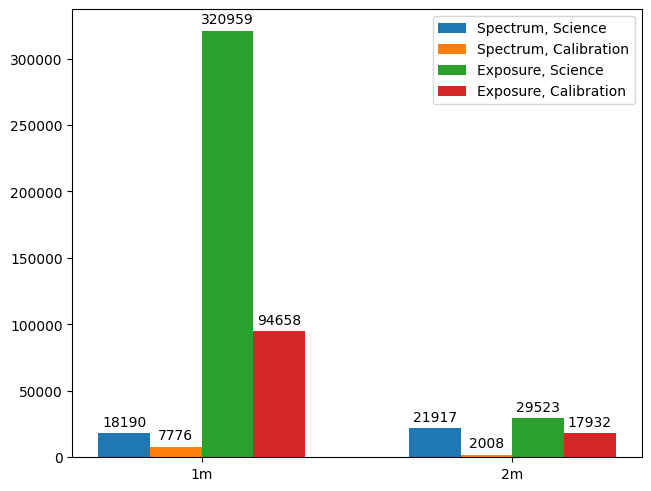

In [34]:
fig, ax = plt.subplots(layout="constrained")
rects = ax.bar([1, 2.5], [counts["1m"][True][True], counts["2m"][True][True]], 0.25, label="Spectrum, Science")
ax.bar_label(rects, padding=3)
rects = ax.bar([1.25, 2.75], [counts["1m"][True][False], counts["2m"][True][False]], 0.25, label="Spectrum, Calibration")
ax.bar_label(rects, padding=3)
rects = ax.bar([1.5, 3], [counts["1m"][False][True], counts["2m"][False][True]], 0.25, label="Exposure, Science")
ax.bar_label(rects, padding=3)
rects = ax.bar([1.75, 3.25], [counts["1m"][False][False], counts["2m"][False][False]], 0.25, label="Exposure, Calibration")
ax.bar_label(rects, padding=3)

ax.set_xticks([1.375, 2.875], ["1m", "2m"])
ax.legend(loc='upper right')


## Duration

In [35]:
def split_on_limits(df, column_name, limits):
    counts = []
    for i in range(len(limits)):
        bottom_limit = limits[i]
        if (i+1) < len(limits):
            top_limit = limits[i+1]
        else:
            top_limit = float("inf")
        counts.append(df[(df[column_name]>bottom_limit) & (df[column_name]<=top_limit)].shape[0])

        print(f"{bottom_limit} -> {top_limit}: {counts[i]}")

    labels = ["<="+str(x) for x in limits[1:]]
    labels.append(str(limits[-1])+"+")
    plt.bar(labels, counts)
    plt.show()

In [36]:
def cumulative_plot(df, column_name):
    quantiles = []
    steps = []
    step = 200
    for i in range(int(step)-10):
        q = df[column_name].quantile(i/step)
        quantiles.append(q)
        steps.append(i/step)
    
    plt.scatter(quantiles, steps, marker=".", color="black")
    # plt.title(title)
    # plt.xlabel(xlabel)
    # plt.ylabel(ylabel)
    # plt.savefig(os.path.join("plots", filename+".png"))
    plt.show()





0 -> 600: 192739
600 -> 1800: 121323
1800 -> inf: 76527


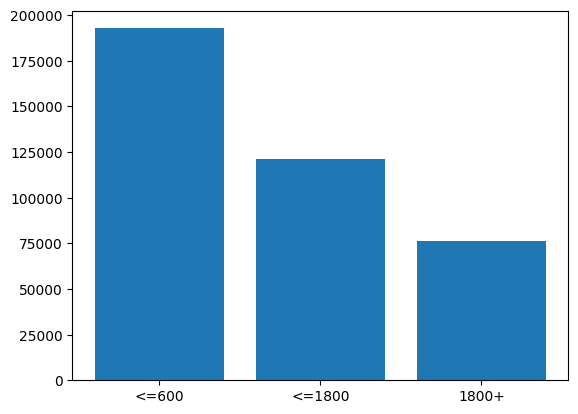

In [37]:
split_on_limits(df[df["science"]], "total_duration", [0, 600, 1800])

0 -> 600: 17743
600 -> 1800: 14587
1800 -> inf: 19110


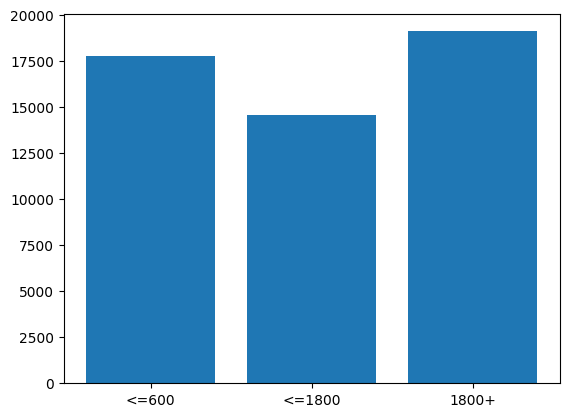

In [38]:
split_on_limits(df[(df["class"]=="2m") & (df["science"])], "total_duration", [0, 600, 1800])

0 -> 300: 92100
300 -> 600: 82896
600 -> 1200: 76983
1200 -> inf: 87170


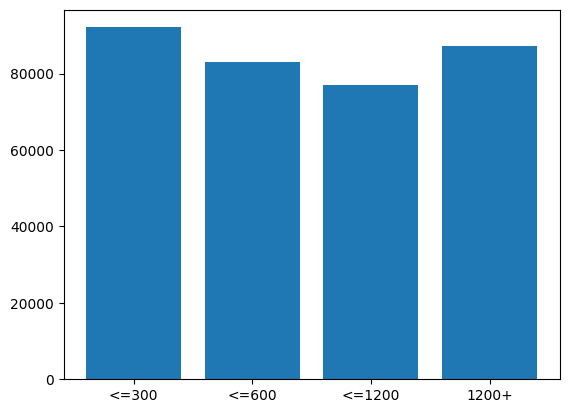

In [39]:
split_on_limits(df[(df["class"]=="1m") & (df["science"])], "total_duration", [0, 300, 600, 1200])

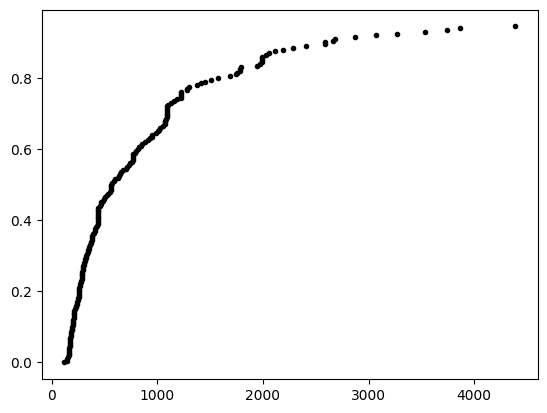

In [40]:
cumulative_plot(df[(df["class"]=="1m") & (df["science"])], "total_duration")

In [41]:
df

,original_windows,windows,request_id,ipp_value,created,proposal_id,optimization_type,total_duration,acceptibility_cutoff,valid_telescopes,class,target_constraint_pairs,science,is_spectrum
2337608,"[{'start': 2020-12-22 07:57:37, 'end': 2020-12...",{'1m0a.doma.tfn': Timestamp('2020-12-23 04:58:...,2337608,1.0,2020-12-22T07:55:38.646Z,KEY2020B-006,TIME,1398,1398.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN,True,False
2149231,"[{'start': 2020-06-13 08:30:19.488000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2020-06-13 21:03:...,2149231,0.9,2020-06-13T08:30:23.476Z,KEY2017AB-001,TIME,2318,2318.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN,True,False
2149281,"[{'start': 2020-06-13 09:50:44.345000, 'end': ...",{'1m0a.doma.tfn': Timestamp('2020-06-13 21:03:...,2149281,1.2,2020-06-13T09:50:49.620Z,KEY2017AB-001,TIME,2025,2025.0,"[1m0a.doma.lsc, 1m0a.domc.cpt, 1m0a.domb.lsc, ...",1m,NaN,True,False
2379046,"[{'start': 2021-02-03 18:35:27.970000, 'end': ...",{'1m0a.domc.cpt': Timestamp('2021-02-03 18:35:...,2379046,1.05,2021-02-03T11:00:24.757Z,auto_focus,TIME,542,542.0,[1m0a.domc.cpt],1m,NaN,False,False
2379039,"[{'start': 2021-02-03 18:35:27.970000, 'end': ...",{'1m0a.domb.cpt': Timestamp('2021-02-03 18:35:...,2379039,1.05,2021-02-03T11:00:16.184Z,auto_focus,TIME,542,542.0,[1m0a.domb.cpt],1m,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2628675,"[{'start': 2021-08-31 18:39:40.818000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-08-31 18:39:...,2628675,1.05,2021-08-31T02:00:52.062Z,auto_focus,TIME,720,720.0,[2m0a.clma.coj],2m,"[{'target': {'id': 6531444, 'name': 'auto_focu...",False,False
2628924,"[{'start': 2021-08-31 11:55:25.041000, 'end': ...",{'2m0a.clma.ogg': Timestamp('2021-08-31 11:55:...,2628924,1.0,2021-08-31T11:55:29.112Z,NSF2021B-019,TIME,1740,1740.0,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6533080, 'name': 'ZTF20acgi...",True,False
2546029,"[{'start': 2021-06-10 00:30:21.276000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-06-10 12:56:...,2546029,1.0,2021-06-10T00:30:30.609Z,KEY2020B-002,TIME,4245,4244.5,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6101526, 'name': 'SN2021hku...",True,True
2625941,"[{'start': 2021-08-28 00:00:04.674000, 'end': ...",{'2m0a.clma.coj': Timestamp('2021-08-28 13:07:...,2625941,0.9,2021-08-28T00:00:21.972Z,KEY2020B-002,TIME,1245,1244.5,"[2m0a.clma.coj, 2m0a.clma.ogg]",2m,"[{'target': {'id': 6516191, 'name': 'SN2021rhu...",True,True


## Availability Length

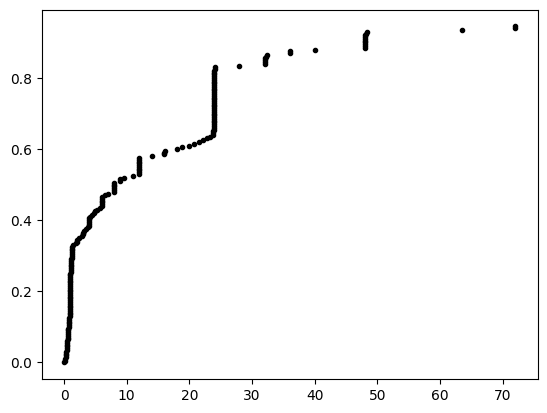

In [42]:
def find_availability_length(og_windows):
    og_windows.sort(key=lambda x: x["start"])
    start = og_windows[0]["start"]
    end = og_windows[-1]["end"]
    td = end - start
    return (td.days*24*60*60 + td.seconds) / (60*60)

df["availability_length"] = df["original_windows"].apply(find_availability_length)
cumulative_plot(df[(df["class"]=="1m") & (df["science"])], "availability_length")

0 -> 0.9: 43943
0.9 -> 1: 40016
1 -> 2: 33782
2 -> 6: 40222
6 -> 11.9: 20907
11.9 -> 12: 16784
12 -> 24: 83937
24 -> 48: 30335
48 -> inf: 29223


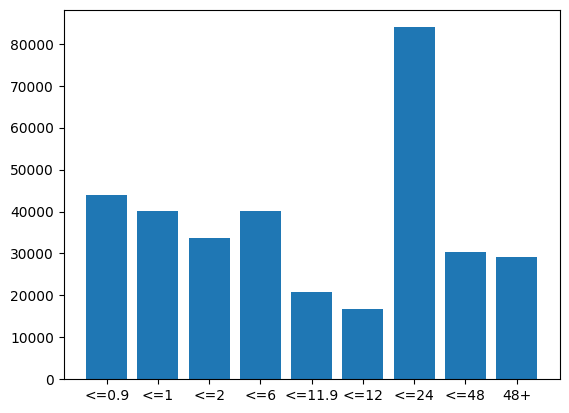

In [44]:
split_on_limits(df[(df["class"]=="1m") & (df["science"])], "availability_length", [0, 0.9, 1, 2, 6, 11.9, 12, 24, 48])